# Visual Question Answering using Multimodal Transformer Models

## Import necessary libraries & set up the environment

In [1]:
import os
from copy import deepcopy
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
from datasets import load_dataset
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from transformers import (
    # Preprocessing / Common
    AutoTokenizer, AutoFeatureExtractor,
    # Text & Image Models (Now, image transformers like ViTModel, DeiTModel, BEiT can also be loaded using AutoModel)
    AutoModel,
    # Training / Evaluation
    TrainingArguments, Trainer,
    # Misc
    logging
)

# import nltk
# nltk.download('wordnet')
from nltk.corpus import wordnet

from sklearn.metrics import accuracy_score, f1_score

In [2]:
# SET CACHE FOR HUGGINGFACE TRANSFORMERS + DATASETS
os.environ['HF_HOME'] = os.path.join(".", "cache")
# SET ONLY 1 GPU DEVICE
os.environ['CUDA_VISIBLE_DEVICES'] = '0'


logging.set_verbosity_error()

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
#     print('Memory Usage:')
#     print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
#     print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

cuda:0
NVIDIA A100-SXM4-40GB


## Load the Processed [DAQUAR Dataset](https://www.mpi-inf.mpg.de/departments/computer-vision-and-machine-learning/research/vision-and-language/visual-turing-challenge/)

All the questions have 1-word/phrase answer, so we consider the entire vocabulary of answers available (*answer space*) & treat them as labels. This converts the visual question answering into a multi-class classification problem.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
base_path = "/content/drive/MyDrive/dataset"

dataset = load_dataset(
    "csv",
    data_files={
        "train": os.path.join(base_path, "data_train.csv"),
        "test": os.path.join(base_path, "data_eval.csv")
    }
)

with open(os.path.join(base_path, "answer_space.txt")) as f:
    answer_space = f.read().splitlines()

# ✅ KEEP THIS
dataset = dataset.map(
    lambda examples: {
        'label': [
            answer_space.index(ans.replace(" ", "").split(",")[0])
            for ans in examples['answer']
        ]
    },
    batched=True
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/9974 [00:00<?, ? examples/s]

Map:   0%|          | 0/2494 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'image_id', 'label'],
        num_rows: 9974
    })
    test: Dataset({
        features: ['question', 'answer', 'image_id', 'label'],
        num_rows: 2494
    })
})

### Look at some of the Question/Image/Answer combinations

In [7]:
from IPython.display import display

def get_image_path(image_id):
    # Try different extensions (safe approach)
    for ext in [".png", ".jpg", ".jpeg"]:
        path = os.path.join(base_path, "images", image_id + ext)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"Image {image_id} not found")

def showExample(train=True, id=None):
    data = dataset["train"] if train else dataset["test"]

    if id is None:
        id = np.random.randint(len(data))

    # ✅ SAFE IMAGE LOADING
    image_path = get_image_path(data[id]["image_id"])
    image = Image.open(image_path)

    display(image)

    print("Question:\t", data[id]["question"])
    print("Answer:\t\t", data[id]["answer"], f"(Label: {data[id]['label']})")

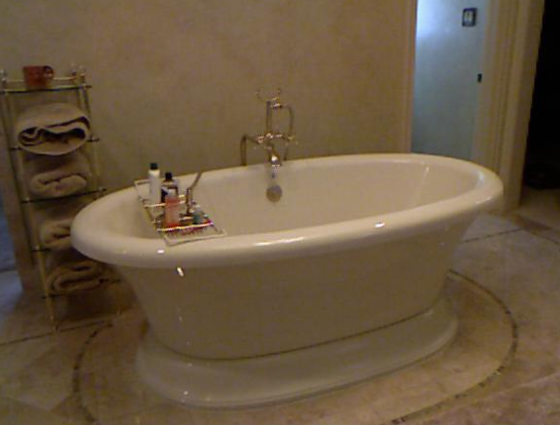

Question:	 what is the largest object
Answer:		 bathtub (Label: 41)


In [8]:
showExample()

### Create a Multimodal Collator for the Dataset

This will be used in the `Trainer()` to automatically create the `Dataloader` from the dataset to pass inputs to the model

The collator will process the **question (text)** & the **image**, and return the **tokenized text (with attention masks)** along with the **featurized image** (basically, the **pixel values**). These will be fed into our multimodal transformer model for question answering.

In [9]:
from transformers import AutoImageProcessor
@dataclass
class MultimodalCollator:
    tokenizer: AutoTokenizer
    preprocessor: AutoImageProcessor

    def get_image_path(self, image_id):
        for ext in [".png", ".jpg", ".jpeg"]:
            path = os.path.join(base_path, "images", image_id + ext)
            if os.path.exists(path):
                return path
        raise FileNotFoundError(f"Image {image_id} not found")

    def tokenize_text(self, texts: List[str]):
        encoded_text = self.tokenizer(
            text=texts,
            padding='longest',
            max_length=24,
            truncation=True,
            return_tensors='pt',
            return_token_type_ids=True,
            return_attention_mask=True,
        )
        return {
            "input_ids": encoded_text['input_ids'],
            "token_type_ids": encoded_text['token_type_ids'],
            "attention_mask": encoded_text['attention_mask'],
        }

    def preprocess_images(self, images: List[str]):
        processed_images = self.preprocessor(
            images=[
                Image.open(self.get_image_path(image_id)).convert('RGB')
                for image_id in images
            ],
            return_tensors="pt",
        )
        return {
            "pixel_values": processed_images['pixel_values'],
        }

    def __call__(self, raw_batch_dict):
        return {
            **self.tokenize_text(
                raw_batch_dict['question']
                if isinstance(raw_batch_dict, dict) else
                [i['question'] for i in raw_batch_dict]
            ),
            **self.preprocess_images(
                raw_batch_dict['image_id']
                if isinstance(raw_batch_dict, dict) else
                [i['image_id'] for i in raw_batch_dict]
            ),
            'labels': torch.tensor(
                raw_batch_dict['label']
                if isinstance(raw_batch_dict, dict) else
                [i['label'] for i in raw_batch_dict],
                dtype=torch.int64
            ),
        }

## Defining the Multimodal VQA Model Architecture

Multimodal models can be of various forms to capture information from the text & image modalities, along with some cross-modal interaction as well.
Here, we explore **"Fusion" Models**, that fuse information from the text encoder & image encoder to perform the downstream task (visual question answering).

The text encoder can be a text-based transformer model (like BERT, RoBERTa, etc.) while the image encoder could be an image transformer (like ViT, Deit, BeIT, etc.). After passing the tokenized question through the text-based transformer & the image features through the image transformer, the outputs are concatenated & passed through a fully-connected network with an output having the same dimensions as the answer-space.

Since we model the VQA task as a multi-class classification, it is natural to use the *Cross-Entropy Loss* as the loss function.

In [10]:
class MultimodalVQAModel(nn.Module):
    def __init__(
            self,
            num_labels: int = len(answer_space),
            intermediate_dim: int = 512,
            pretrained_text_name: str = 'bert-base-uncased',
            pretrained_image_name: str = 'google/vit-base-patch16-224-in21k'):

        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(pretrained_text_name)
        self.image_encoder = AutoModel.from_pretrained(pretrained_image_name)

        self.fusion = nn.Sequential(
            nn.Linear(
                self.text_encoder.config.hidden_size +
                self.image_encoder.config.hidden_size,
                intermediate_dim
            ),
            nn.ReLU(),
            nn.Dropout(0.5),
        )

        self.classifier = nn.Linear(intermediate_dim, num_labels)
        self.criterion = nn.CrossEntropyLoss()

    def forward(
            self,
            input_ids,
            pixel_values,
            attention_mask=None,
            token_type_ids=None,
            labels=None):

        # Text encoder
        text_out = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )

        # Image encoder
        image_out = self.image_encoder(
            pixel_values=pixel_values,
            return_dict=True,
        )

        # ✅ FIXED: use correct outputs
        text_feat = text_out.pooler_output
        image_feat = image_out.last_hidden_state[:, 0]

        fused = self.fusion(
            torch.cat([text_feat, image_feat], dim=1)
        )

        logits = self.classifier(fused)

        output = {"logits": logits}

        if labels is not None:
            loss = self.criterion(logits, labels)
            output["loss"] = loss

        return output

### Define a Function to Create the Multimodal VQA Models along with their Collators

We plan to experiment with multiple pretrained text & image encoders for our VQA Model. Thus, we will have to create the corresponding collators along with the model (tokenizers, featurizers & models need to be loaded from same pretrained checkpoints)

In [11]:
def createMultimodalVQACollatorAndModel(text='bert-base-uncased', image='google/vit-base-patch16-224-in21k'):
    tokenizer = AutoTokenizer.from_pretrained(text)
    from transformers import AutoImageProcessor
    preprocessor = AutoImageProcessor.from_pretrained(image)

    multi_collator = MultimodalCollator(
        tokenizer=tokenizer,
        preprocessor=preprocessor,
    )


    multi_model = MultimodalVQAModel(pretrained_text_name=text, pretrained_image_name=image).to(device)
    return multi_collator, multi_model

## Performance Metrics from Visual Question Answering

### Wu and Palmer Similarity

The Wu & Palmer similarity is a metric to calculate the sematic similarity between 2 words/phrases based on the position of concepts $c_1$ and $c_2$ in the taxonomy, relative to the position of their **_Least Common Subsumer_** $LCS(c_1, c_2)$. *(In an directed acyclic graph, the Least Common Subsumer is the is the deepest node that has both the nodes under consideration as descendants, where we define each node to be a descendant of itself)*

WUP similarity works for single-word answers (& hence, we use if for our task), but doesn't work for phrases or sentences.

`nltk` has an implementation of Wu & Palmer similarity score based on the WordNet taxanomy. Here, we have adapted the [implementation of Wu & Palmer similarity as defined along with the DAQUAR dataset](https://datasets.d2.mpi-inf.mpg.de/mateusz14visual-turing/calculate_wups.py).


In [12]:
import nltk
nltk.download('wordnet')
def wup_measure(a,b,similarity_threshold=0.925):
    """
    Returns Wu-Palmer similarity score.
    More specifically, it computes:
        max_{x \in interp(a)} max_{y \in interp(b)} wup(x,y)
        where interp is a 'interpretation field'
    """
    def get_semantic_field(a):
        weight = 1.0
        semantic_field = wordnet.synsets(a,pos=wordnet.NOUN)
        return (semantic_field,weight)


    def get_stem_word(a):
        """
        Sometimes answer has form word\d+:wordid.
        If so we return word and downweight
        """
        weight = 1.0
        return (a,weight)


    global_weight=1.0

    (a,global_weight_a)=get_stem_word(a)
    (b,global_weight_b)=get_stem_word(b)
    global_weight = min(global_weight_a,global_weight_b)

    if a==b:
        # they are the same
        return 1.0*global_weight

    if a==[] or b==[]:
        return 0


    interp_a,weight_a = get_semantic_field(a)
    interp_b,weight_b = get_semantic_field(b)

    if interp_a == [] or interp_b == []:
        return 0

    # we take the most optimistic interpretation
    global_max=0.0
    for x in interp_a:
        for y in interp_b:
            local_score = x.wup_similarity(y) or 0
            if local_score > global_max:
                global_max=local_score

    # we need to use the semantic fields and therefore we downweight
    # unless the score is high which indicates both are synonyms
    if global_max < similarity_threshold:
        interp_weight = 0.1
    else:
        interp_weight = 1.0

    final_score=global_max*weight_a*weight_b*interp_weight*global_weight
    return final_score

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:18: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_400/4182455447.py:7: SyntaxWarning: invalid escape sequence '\i'
  max_{x \in interp(a)} max_{y \in interp(b)} wup(x,y)
/tmp/ipykernel_400/4182455447.py:18: SyntaxWarning: invalid escape sequence '\d'
  Sometimes answer has form word\d+:wordid.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [13]:
def batch_wup_measure(labels, preds):
    wup_scores = [wup_measure(answer_space[label], answer_space[pred]) for label, pred in zip(labels, preds)]
    return np.mean(wup_scores)

In [14]:
labels = np.random.randint(len(answer_space), size=5)
preds = np.random.randint(len(answer_space), size=5)

def showAnswers(ids):
    print([answer_space[id] for id in ids])

showAnswers(labels)
showAnswers(preds)

print("Predictions vs Labels: ", batch_wup_measure(labels, preds))
print("Labels vs Labels: ", batch_wup_measure(labels, labels))

['13', 'lighting_track', 'show_piece', 'notecards', 'desk']
['hockey_glove', 'kitchen_island', 'pan', 'radiator', 'basketball']
Predictions vs Labels:  0.012
Labels vs Labels:  1.0


In [15]:
def compute_metrics(eval_tuple: Tuple[np.ndarray, np.ndarray]) -> Dict[str, float]:
    logits, labels = eval_tuple
    preds = logits.argmax(axis=-1)
    return {
        "wups": batch_wup_measure(labels, preds),
        "acc": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average='macro')
    }

## Model Training & Evaluation

### Define the Arguments needed for Training

In [16]:
args = TrainingArguments(
    output_dir="checkpoint",
    seed=12345,
    eval_strategy="steps",
    eval_steps=100,
    logging_strategy="steps",
    logging_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=3,             # Save only the last 3 checkpoints at any given time while training
    metric_for_best_model='wups',
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    remove_unused_columns=False,
    num_train_epochs=5,
    fp16=True,
    # warmup_ratio=0.01,
    # learning_rate=5e-4,
    # weight_decay=1e-4,
    # gradient_accumulation_steps=2,
    dataloader_num_workers=8,
    load_best_model_at_end=True,
)

### Create the Multimodal Models using User-Defined Text/Image  Transformers & Train it on the Dataset

In [17]:
def createAndTrainModel(dataset, args, text_model='bert-base-uncased', image_model='google/vit-base-patch16-224-in21k', multimodal_model='bert_vit'):
    collator, model = createMultimodalVQACollatorAndModel(text_model, image_model)

    multi_args = deepcopy(args)
    multi_args.output_dir = os.path.join("..", "checkpoint", multimodal_model)
    multi_trainer = Trainer(
        model,
        multi_args,
        train_dataset=dataset['train'],
        eval_dataset=dataset['test'],
        data_collator=collator,
        compute_metrics=compute_metrics
    )

    train_multi_metrics = multi_trainer.train()
    eval_multi_metrics = multi_trainer.evaluate()

    return collator, model, train_multi_metrics, eval_multi_metrics

In [18]:
collator, model, train_multi_metrics, eval_multi_metrics = createAndTrainModel(dataset, args)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

{'loss': '5.827', 'grad_norm': '5.129', 'learning_rate': '4.683e-05', 'epoch': '0.3205'}
{'eval_loss': '5.193', 'eval_wups': '0.1345', 'eval_acc': '0.07698', 'eval_f1': '0.00159', 'eval_runtime': '33.56', 'eval_samples_per_second': '74.31', 'eval_steps_per_second': '2.324', 'epoch': '0.3205'}
{'loss': '5.066', 'grad_norm': '5.602', 'learning_rate': '4.362e-05', 'epoch': '0.641'}
{'eval_loss': '4.715', 'eval_wups': '0.1725', 'eval_acc': '0.1159', 'eval_f1': '0.003538', 'eval_runtime': '15.17', 'eval_samples_per_second': '164.4', 'eval_steps_per_second': '5.143', 'epoch': '0.641'}
{'loss': '4.805', 'grad_norm': '5.768', 'learning_rate': '4.042e-05', 'epoch': '0.9615'}
{'eval_loss': '4.472', 'eval_wups': '0.1932', 'eval_acc': '0.1267', 'eval_f1': '0.004489', 'eval_runtime': '13.34', 'eval_samples_per_second': '187', 'eval_steps_per_second': '5.849', 'epoch': '0.9615'}
{'loss': '4.508', 'grad_norm': '5.549', 'learning_rate': '3.721e-05', 'epoch': '1.282'}
{'eval_loss': '4.243', 'eval_wups'

In [19]:
eval_multi_metrics

{'eval_loss': 3.714742422103882,
 'eval_wups': 0.27474329056929775,
 'eval_acc': 0.22614274258219727,
 'eval_f1': 0.017313277203374253,
 'eval_runtime': 14.1074,
 'eval_samples_per_second': 176.786,
 'eval_steps_per_second': 5.529,
 'epoch': 5.0}

## Examples of Model Inferencing

### Loading the Model from Checkpoint

In [20]:
model = MultimodalVQAModel()

# We use the checkpoint giving best results
model.load_state_dict(torch.load(os.path.join("..", "checkpoint", "bert_vit", "checkpoint-1500", "pytorch_model.bin")))
model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '../checkpoint/bert_vit/checkpoint-1500/pytorch_model.bin'

In [ ]:
sample = collator(dataset["test"][2000:2005])

input_ids = sample["input_ids"].to(device)
token_type_ids = sample["token_type_ids"].to(device)
attention_mask = sample["attention_mask"].to(device)
pixel_values = sample["pixel_values"].to(device)
labels = sample["labels"].to(device)

### Pass the Samples through the Model & inspect the Predictions

In [ ]:
model.eval()
output = model(input_ids, pixel_values, attention_mask, token_type_ids, labels)

In [ ]:
preds = output["logits"].argmax(axis=-1).cpu().numpy()
preds

In [ ]:
for i in range(2000, 2005):
    print("*********************************************************")
    showExample(train=False, id=i)
    print("Predicted Answer:\t", answer_space[preds[i-2000]])
    print("*********************************************************")

## Inspecting Model Size

In [ ]:
def countTrainableParameters(model):
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("No. of trainable parameters:\t{0:,}".format(num_params))

In [ ]:
countTrainableParameters(model) # For BERT-ViT model